## **IMPORTING DATASET**

In [6]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset



Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:23<00:00, 122MB/s]



In [ ]:
!unzip new-plant-diseases-dataset.zip

# **IMMPORTING LIBRARIES**

In [8]:


import numpy as np
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor

import plotly.graph_objs as go
import plotly.subplots as sp
from plotly.subplots import make_subplots
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

import os
import random
from PIL import Image

import warnings
warnings.filterwarnings("ignore")



In [9]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense ,Conv2D,MaxPooling2D,Flatten,Dropout,BatchNormalization
import matplotlib.pyplot as plt
from tensorflow.keras.layers import GlobalAveragePooling2D
from keras.callbacks import EarlyStopping, ModelCheckpoint,ReduceLROnPlateau


In [18]:
from keras.layers import Rescaling

**CLASSES NAMES**

In [87]:
from pathlib import Path

data_dir = Path('/content/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train')

class_name = [item.name for item in data_dir.glob('*') if item.is_dir()]
print(class_name)

['Cherry_(including_sour)___Powdery_mildew', 'Peach___healthy', 'Apple___Cedar_apple_rust', 'Cherry_(including_sour)___healthy', 'Potato___Early_blight', 'Strawberry___healthy', 'Potato___Late_blight', 'Blueberry___healthy', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Orange___Haunglongbing_(Citrus_greening)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Tomato___Bacterial_spot', 'Pepper,_bell___Bacterial_spot', 'Apple___healthy', 'Grape___healthy', 'Tomato___Septoria_leaf_spot', 'Tomato___Late_blight', 'Tomato___Target_Spot', 'Pepper,_bell___healthy', 'Apple___Black_rot', 'Tomato___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Potato___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Squash___Powdery_mildew', 'Corn_(maize)___Common_rust_', 'Tomato___Early_blight', 'Grape___Esca_(Black_Measles)', 'Strawberry___Leaf_scorch', 'Corn_(maize)___healthy', 'Tomato___Leaf_Mold', 'Apple___Apple_scab', 'Peach___Bacterial_spot'

# **TEST AND VALIDATION DATASET**

In [98]:
train = tf.keras.utils.image_dataset_from_directory(
    '/content/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train',
    labels = 'inferred',
    label_mode = 'categorical',
    batch_size = 128,
    image_size = (256, 256),
    class_names=class_name,
    shuffle = True,
    validation_split = 0,
    crop_to_aspect_ratio = True
)

Found 70295 files belonging to 38 classes.


In [99]:
validation = tf.keras.utils.image_dataset_from_directory(
    '/content/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid',
    labels = 'inferred',
    label_mode = 'categorical',
    batch_size = 128,
    image_size = (256, 256),
    class_names=class_name,
    shuffle = True,
    validation_split = 0,
    crop_to_aspect_ratio = True
)

Found 17572 files belonging to 38 classes.


***RESCALLING**

In [100]:
scaler = Rescaling(1./255)

In [101]:
# Rescaling datasets
train = train.map(lambda x, y: (scaler(x), y))
test = test.map(lambda x, y: (scaler(x), y))
validation = validation.map(lambda x, y: (scaler(x), y))

In [102]:
seed = 42

# **AUGMENTATION**

In [103]:

# Creating data augmentation pipeline
augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomRotation(
        factor = (-.25, .3),
        fill_mode = 'reflect',
        interpolation = 'bilinear',
        seed = seed),


        tf.keras.layers.RandomBrightness(
        factor = (-.45, .45),
        value_range = (0.0, 1.0),
        seed = seed),

        tf.keras.layers.RandomContrast(
        factor = (.5),
        seed = seed)
    ]
)


In [95]:
augmentation.build((None, 256, 256, 3)) # Building model


# ***MODEL PIPELINE***

In [105]:
model=Sequential()



model.add(Conv2D(16,(3,3),strides = 1, padding = 'same',activation='relu',input_shape = (256,256,3) ))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), padding = 'same'))



model.add(Conv2D(32, (3,3),activation='relu',padding = 'same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), padding = 'same'))


model.add(Conv2D(64, (3,3),activation='relu', padding = 'same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), padding = 'same'))


model.add(Conv2D(64, (3,3), activation='relu',padding = 'same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), padding = 'same'))


model.add(Conv2D(64, (3,3),activation='relu', padding = 'same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), padding = 'same'))


model.add(GlobalAveragePooling2D())

 # Fully-Connected Layers
model.add(Dense(128,activation='relu',))


# Output Layer
model.add(Dense(38, activation = 'softmax'))



In [106]:
model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_70 (Conv2D)              │ (None, 256, 256, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_65          │ (None, 256, 256, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_65 (MaxPooling2D) │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_71 (Conv2D)              │ (None, 128, 128, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_66          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_66 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_72 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_67          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_67 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_68          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_68 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_74 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_69          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_69 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,622 (436.02 KB)

 Trainable params: 111,142 (434.15 KB)

 Non-trainable params: 480 (1.88 KB)

In [107]:
# Compiling model
model.compile(optimizer = tf.keras.optimizers.Adam(0.0005), loss = 'categorical_crossentropy', metrics = ['accuracy'])

**EARLY STOPPING AND CHECKPOINTS**

In [110]:

early_stopping = EarlyStopping(monitor = 'val_loss',patience = 10, mode = 'min',restore_best_weights = True)

checkpoint = ModelCheckpoint('best_model.keras',monitor = 'val_loss',save_best_only = True,mode='min')

lr_scheduler = ReduceLROnPlateau( monitor='val_loss', factor=0.3, patience=3,min_lr=1e-6)



In [111]:
try:
    history = model.fit(
        train, epochs = 12,
        validation_data = validation,
        callbacks = [early_stopping, checkpoint,lr_scheduler])
except Exception as e:
    print("An error occurred:", e)

Epoch 1/12
550/550 ━━━━━━━━━━━━━━━━━━━━ 109s 198ms/step - accuracy: 0.9426 - loss: 0.2048 - val_accuracy: 0.8875 - val_loss: 0.3396 - learning_rate: 5.0000e-04
Epoch 2/12
550/550 ━━━━━━━━━━━━━━━━━━━━ 141s 196ms/step - accuracy: 0.9603 - loss: 0.1337 - val_accuracy: 0.8857 - val_loss: 0.3425 - learning_rate: 5.0000e-04
Epoch 3/12
550/550 ━━━━━━━━━━━━━━━━━━━━ 110s 199ms/step - accuracy: 0.9714 - loss: 0.0987 - val_accuracy: 0.9319 - val_loss: 0.2093 - learning_rate: 5.0000e-04
Epoch 4/12
550/550 ━━━━━━━━━━━━━━━━━━━━ 110s 199ms/step - accuracy: 0.9769 - loss: 0.0774 - val_accuracy: 0.9552 - val_loss: 0.1377 - learning_rate: 5.0000e-04
Epoch 5/12
550/550 ━━━━━━━━━━━━━━━━━━━━ 109s 199ms/step - accuracy: 0.9813 - loss: 0.0636 - val_accuracy: 0.8735 - val_loss: 0.4521 - learning_rate: 5.0000e-04
Epoch 6/12
550/550 ━━━━━━━━━━━━━━━━━━━━ 116s 212ms/step - accuracy: 0.9829 - loss: 0.0557 - val_accuracy: 0.9627 - val_loss: 0.1118 - learning_rate: 5.0000e-04
Epoch 7/12
550/550 ━━━━━━━━━━━━━━━━━━━━ 

In [112]:
model.save('model.keras')

In [113]:
from google.colab import files
files.download('model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **TEST EVALUATION**

In [142]:
test_loss,test_acc = model.evaluate(validation)
print('Test accuracy:', test_acc)


138/138 ━━━━━━━━━━━━━━━━━━━━ 17s 112ms/step - accuracy: 0.9893 - loss: 0.0331
Test accuracy: 0.9893011450767517


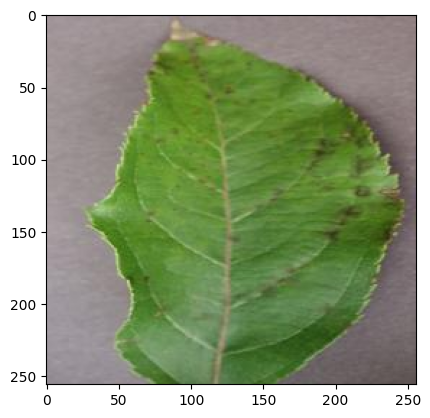

In [150]:
from tensorflow.keras.preprocessing import image
img_path = "/content/test/test/AppleScab1.JPG"

img = image.load_img(img_path, target_size=(256,256))
plt.imshow(img)
img_array = image.img_to_array(img)
img_array = img_array / 255.0   # normalization
img_array = np.expand_dims(img_array, axis=0)

In [151]:
pred = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [152]:
pred_class = class_names[np.argmax(pred)]
print("Prediction:", pred_class)

Prediction: Apple___Apple_scab


# REPRESENTATION

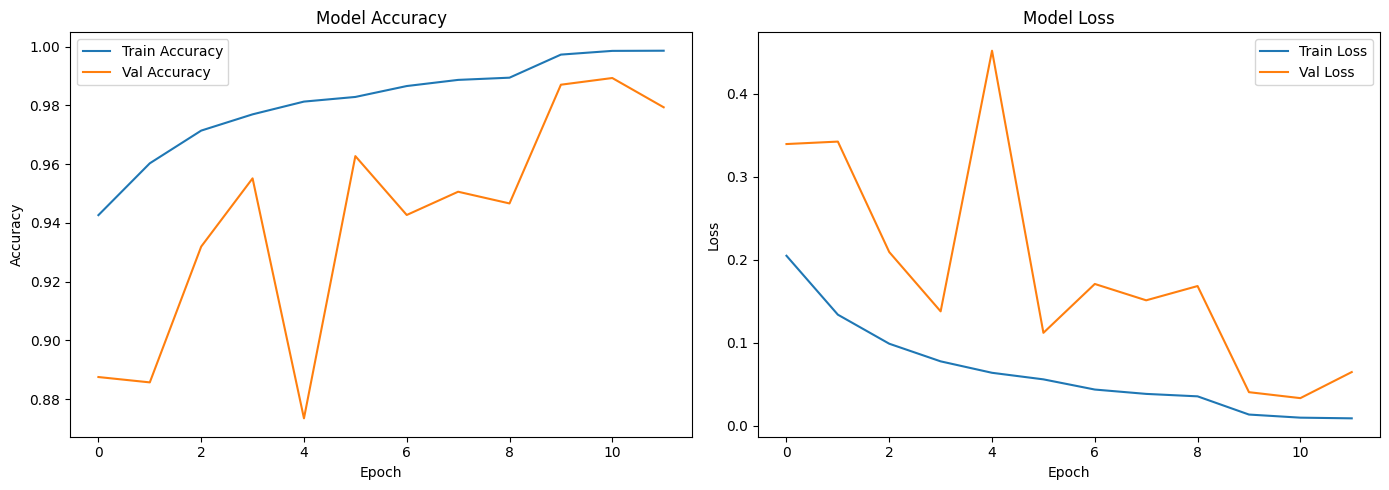

In [133]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()